In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Change to models/seirs_sei directory
os.chdir(os.path.dirname(os.path.abspath('.')) + '/seirs_sei')
print(f'Working directory: {os.getcwd()}')

Working directory: C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei


In [2]:
# ============================================================================
# LOAD SAVED MODEL RESULTS FROM CSV FILES
# ============================================================================

print('Loading saved model results from CSV files...')

results_no_intervention = pd.read_csv('../../models/results/model_results_no_intervention.csv')
results_with_intervention = pd.read_csv('../../models/results/model_results_with_intervention.csv')

print(f'No Intervention model: {len(results_no_intervention)} time points')
print(f'With Intervention model: {len(results_with_intervention)} time points')

# Create combined comparison DataFrame
comparison_results = pd.DataFrame({
    'year': results_no_intervention['year'],
    'I_H_no_intervention': results_no_intervention['I_H'],
    'I_H_with_intervention': results_with_intervention['I_H'],
    'E_H_no_intervention': results_no_intervention['E_H'],
    'E_H_with_intervention': results_with_intervention['E_H'],
    'R_H_no_intervention': results_no_intervention['R_H'],
    'R_H_with_intervention': results_with_intervention['R_H'],
    'S_H_no_intervention': results_no_intervention['S_H'],
    'S_H_with_intervention': results_with_intervention['S_H'],
    'S_M_no_intervention': results_no_intervention['S_M'],
    'S_M_with_intervention': results_with_intervention['S_M'],
    'E_M_no_intervention': results_no_intervention['E_M'],
    'E_M_with_intervention': results_with_intervention['E_M'],
    'I_M_no_intervention': results_no_intervention['I_M'],
    'I_M_with_intervention': results_with_intervention['I_M'],
    'difference': results_no_intervention['I_H'] - results_with_intervention['I_H'],
    'reduction_percent': (results_no_intervention['I_H'] - results_with_intervention['I_H']) / 
                         results_no_intervention['I_H'].replace(0, np.nan) * 100
})

print('\nComparison DataFrame created!')
print(f'Shape: {comparison_results.shape}')
print('\nColumns:')
print(comparison_results.columns.tolist())


Loading saved model results from CSV files...
No Intervention model: 2557 time points
With Intervention model: 2557 time points

Comparison DataFrame created!
Shape: (2557, 17)

Columns:
['year', 'I_H_no_intervention', 'I_H_with_intervention', 'E_H_no_intervention', 'E_H_with_intervention', 'R_H_no_intervention', 'R_H_with_intervention', 'S_H_no_intervention', 'S_H_with_intervention', 'S_M_no_intervention', 'S_M_with_intervention', 'E_M_no_intervention', 'E_M_with_intervention', 'I_M_no_intervention', 'I_M_with_intervention', 'difference', 'reduction_percent']


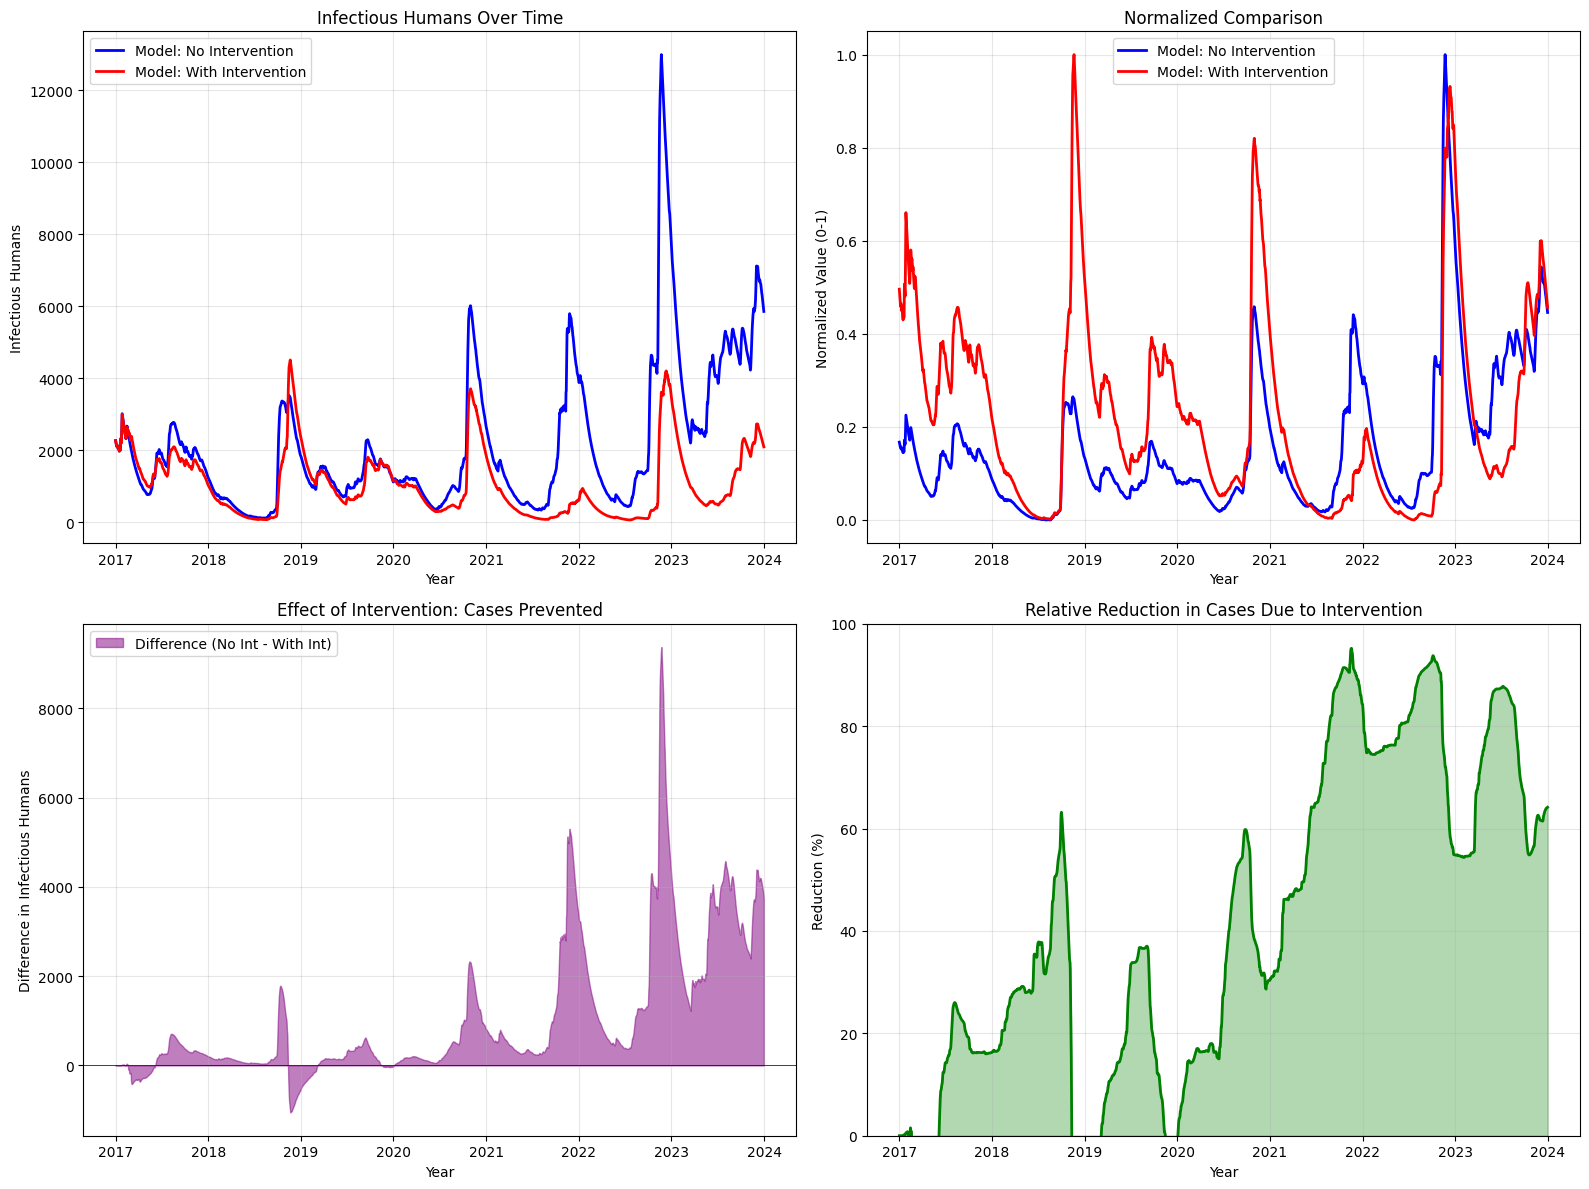

In [3]:
# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Infectious Humans - Both Models
ax = axes[0, 0]
ax.plot(comparison_results['year'], comparison_results['I_H_no_intervention'], 
        'b-', linewidth=2, label='Model: No Intervention')
ax.plot(comparison_results['year'], comparison_results['I_H_with_intervention'], 
        'r-', linewidth=2, label='Model: With Intervention')
ax.set_xlabel('Year')
ax.set_ylabel('Infectious Humans')
ax.set_title('Infectious Humans Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Normalized Comparison
ax = axes[0, 1]
I_no_int = comparison_results['I_H_no_intervention'].values
I_with_int = comparison_results['I_H_with_intervention'].values

I_no_int_norm = (I_no_int - I_no_int.min()) / (I_no_int.max() - I_no_int.min())
I_with_int_norm = (I_with_int - I_with_int.min()) / (I_with_int.max() - I_with_int.min())

ax.plot(comparison_results['year'], I_no_int_norm, 
        'b-', linewidth=2, label='Model: No Intervention')
ax.plot(comparison_results['year'], I_with_int_norm, 
        'r-', linewidth=2, label='Model: With Intervention')
ax.set_xlabel('Year')
ax.set_ylabel('Normalized Value (0-1)')
ax.set_title('Normalized Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Difference between models
ax = axes[1, 0]
years_diff = comparison_results['year'].values
diff = comparison_results['difference'].values
ax.fill_between(years_diff, 0, diff, alpha=0.5, color='purple', 
               label='Difference (No Int - With Int)')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Difference in Infectious Humans')
ax.set_title('Effect of Intervention: Cases Prevented')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Relative reduction
ax = axes[1, 1]
reduction = comparison_results['reduction_percent'].values
reduction = np.where(np.isfinite(reduction), reduction, 0)
ax.plot(years_diff, reduction, 'g-', linewidth=2)
ax.fill_between(years_diff, 0, reduction, alpha=0.3, color='green')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Reduction (%)')
ax.set_title('Relative Reduction in Cases Due to Intervention')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()


In [4]:
# ============================================================================
# STATISTICAL SUMMARY
# ============================================================================
print('='*70)
print('MODEL COMPARISON SUMMARY')
print('='*70)

print('\n1. INFECTIOUS HUMANS STATISTICS:')
print('-'*50)
print(f"{'Metric':<30} {'No Intervention':<20} {'With Intervention':<20}")
print('-'*50)
print(f"{'Mean':<30} {comparison_results['I_H_no_intervention'].mean():>15.1f} {comparison_results['I_H_with_intervention'].mean():>15.1f}")
print(f"{'Max (Peak)':<30} {comparison_results['I_H_no_intervention'].max():>15.1f} {comparison_results['I_H_with_intervention'].max():>15.1f}")
print(f"{'Min':<30} {comparison_results['I_H_no_intervention'].min():>15.1f} {comparison_results['I_H_with_intervention'].min():>15.1f}")
print(f"{'Std Dev':<30} {comparison_results['I_H_no_intervention'].std():>15.1f} {comparison_results['I_H_with_intervention'].std():>15.1f}")

print('\n2. INTERVENTION EFFECT:')
print('-'*50)
mean_no_int = comparison_results['I_H_no_intervention'].mean()
mean_with_int = comparison_results['I_H_with_intervention'].mean()
avg_reduction = (mean_no_int - mean_with_int) / mean_no_int * 100

print(f"Average cases prevented per day: {mean_no_int - mean_with_int:.1f}")
print(f"Average reduction: {avg_reduction:.1f}%")

total_no_int = comparison_results['I_H_no_intervention'].sum()
total_with_int = comparison_results['I_H_with_intervention'].sum()
cases_prevented = total_no_int - total_with_int

print(f"\nTotal person-days without intervention: {total_no_int:,.0f}")
print(f"Total person-days with intervention: {total_with_int:,.0f}")
print(f"Total cases prevented: {cases_prevented:,.0f} person-days")

print('\n3. PEAK COMPARISON:')
print('-'*50)
peak_no_int = comparison_results['I_H_no_intervention'].max()
peak_with_int = comparison_results['I_H_with_intervention'].max()
print(f"Peak without intervention: {peak_no_int:.0f}")
print(f"Peak with intervention: {peak_with_int:.0f}")
print(f"Peak reduction: {(peak_no_int - peak_with_int) / peak_no_int * 100:.1f}%")

print('\n' + '='*70)
print('MODEL NOTES:')
print('='*70)
print('''
- Model WITHOUT intervention: baseline transmission (no control measures)
- Model WITH intervention: time-varying control effects (bed nets, treatment, etc.)
- Intervention grows exponentially: control_effect = 0.40 * (1 - exp(-t / 2.5))
''')
print('='*70)


MODEL COMPARISON SUMMARY

1. INFECTIOUS HUMANS STATISTICS:
--------------------------------------------------
Metric                         No Intervention      With Intervention   
--------------------------------------------------
Mean                                    2144.7          1080.8
Max (Peak)                             12989.6          4511.9
Min                                      121.4            70.6
Std Dev                                 1978.4           924.0

2. INTERVENTION EFFECT:
--------------------------------------------------
Average cases prevented per day: 1063.9
Average reduction: 49.6%

Total person-days without intervention: 5,484,013
Total person-days with intervention: 2,763,716
Total cases prevented: 2,720,297 person-days

3. PEAK COMPARISON:
--------------------------------------------------
Peak without intervention: 12990
Peak with intervention: 4512
Peak reduction: 65.3%

MODEL NOTES:

- Model WITHOUT intervention: baseline transmission (no con

In [5]:
# ============================================================================
# SAVE COMBINED RESULTS
# ============================================================================

comparison_results.to_csv('../results/comparison_results.csv', index=False)
print('Saved to comparison_results.csv')
print(f'Shape: {comparison_results.shape}')
print('\nFirst 5 rows:')
print(comparison_results.head())


Saved to comparison_results.csv
Shape: (2557, 17)

First 5 rows:
          year  I_H_no_intervention  I_H_with_intervention  \
0  2017.000000          2273.000000            2273.000000   
1  2017.002738          2235.116667            2235.116667   
2  2017.005476          2197.233333            2197.233333   
3  2017.008214          2160.022876            2160.022876   
4  2017.010951          2135.656616            2135.638884   

   E_H_no_intervention  E_H_with_intervention  R_H_no_intervention  \
0          1136.500000            1136.500000             0.000000   
1          1136.500000            1136.500000            37.883333   
2          1136.500000            1136.500000            75.766667   
3          1136.499996            1136.499996           112.866538   
4          1133.135994            1133.141121           148.557701   

   R_H_with_intervention  S_H_no_intervention  S_H_with_intervention  \
0               0.000000          5148.500000            5148.500000 